Autor: Samantha Batisti  
Data: Março 2026

# Análise de Receita - Case Hotel

## Objetivo

O objetivo desta análise é identificar oportunidades para aumentar a receita anual do hotel em 20%.

A abordagem utilizada não se baseia apenas em prever receita futura, mas sim em identificar drivers operacionais de receita, como:

- comportamento de cancelamento
- canais de aquisição
- sazonalidade da demanda
- antecedência das reservas
- tipos de quarto,etc

A partir desses fatores, buscamos identificar *alavancas práticas de negócio* capazes de aumentar a receita do hotel.

## Metodologia de Análise

A análise será conduzida em três etapas principais:

1. Exploração inicial dos dados para compreender a estrutura do dataset e a qualidade das informações.
2. Criação de métricas de negócio relevantes, como duração total da estadia e estimativa de receita por reserva.
3. Análise exploratória para identificar padrões relacionados a cancelamentos, comportamento de reserva e drivers de receita.

## Perguntas de Negócio

Para orientar a análise, foram definidas algumas perguntas principais:

1. Como a receita do hotel está distribuída entre meses, segmentos e tipos de quarto?

2. Qual é a taxa de cancelamento e onde estão os principais vazamentos de receita?

3. Quais características das reservas estão associadas a maior probabilidade de cancelamento?

4. Quais segmentos e perfis de clientes geram maior valor para o hotel?

5. Quais alavancas operacionais podem contribuir para aumentar a receita do hotel?

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

pd.set_option("display.max_columns", None)

In [84]:
arquivo = pd.ExcelFile(r"C:\Users\Samanta\Documents\hotel-case\data\Case Hotel BA .xlsx")
print(arquivo.sheet_names)

['Dicionário Candidato', 'Base de Dados']


In [85]:
dicionario = pd.read_excel(
    r"C:\Users\Samanta\Documents\hotel-case\data\Case Hotel BA .xlsx",
    sheet_name="Dicionário Candidato"
)

dicionario

,,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Nome Coluna,Descrição,NaN,NaN,alimentacao,significado
1,reserva_cancelada,1 = reserva cancelada | 0 = reserva mantida,NaN,NaN,BB,Café da Manhã (Bed and Breakfast)
2,tempo_antecedencia,Número de dias de antecedência da reserva fren...,NaN,NaN,FB,Alimentação livre (Full Board)
3,data_chegada,Data da chegada no hotel,NaN,NaN,HB,Café da Manhã + Outra refeição (Half Board)
4,ano_chegada,Ano da chegada no hotel,NaN,NaN,SC,Sem alimentação
5,mes_chegada,Mês da chegada no hotel,NaN,NaN,Undefined,Sem alimentação
6,diadomes_chegada,Dia do mês da chegada no hotel,NaN,NaN,NaN,NaN
7,nro_noites_fds,Números de noites de FDS de estadia (# Sábados...,NaN,NaN,segmento_mercado,significado
8,nro_noites_dds,Números de noites de DDS de estadia (# Seg - Sex),NaN,NaN,Corporativo,Corporativo
9,adultos,Número de adultos na reserva,NaN,NaN,Direta,Compra direta


# EDA

In [86]:
df = pd.read_excel(
    r"C:\Users\Samanta\Documents\hotel-case\data\Case Hotel BA .xlsx",
    sheet_name="Base de Dados"
)

**Entendimento inicial dos dados**

In [87]:
print("Linhas e colunas:", df.shape)
display(df.head())
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(15))

Linhas e colunas: (39859, 22)


,reserva_cancelada,tempo_antecedencia,data_chegada,ano_chegada,mes_chegada,diadomes_chegada,nro_noites_fds,nro_noites_dds,adultos,criancas,bebes,alimentacao,país,segmento_mercado,cliente_recorrente,tipo_quarto,tipo_pgto,agencia_turismo,receita_por_noite,pedidos_especiais,status_reserva,data_status_reserva
0,1,75,2015-07-01 00:00:00,2015,7,1,0,3,2,0,0,HB,PRT,AT Offline,0,D,Sem pgto,15.0,105.5,0,Cancelada,2015-04-22
1,1,85,2015-07-01 00:00:00,2015,7,1,0,3,2,0,0,BB,PRT,AT Online,0,A,Sem pgto,240.0,82.0,1,Cancelada,2015-05-06
2,1,60,2015-07-01 00:00:00,2015,7,1,2,5,2,0,0,BB,PRT,AT Online,0,E,Sem pgto,240.0,107.0,2,Cancelada,2015-05-11
3,1,96,2015-07-01 00:00:00,2015,7,1,2,8,2,0,0,BB,PRT,Direta,0,E,Sem pgto,NaN,108.3,2,Cancelada,2015-05-29
4,1,23,2015-07-01 00:00:00,2015,7,1,0,4,2,0,0,BB,PRT,AT Online,0,E,Sem pgto,240.0,123.0,0,Cancelada,2015-06-23


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39859 entries, 0 to 39858
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   reserva_cancelada    39859 non-null  int64         
 1   tempo_antecedencia   39859 non-null  int64         
 2   data_chegada         39859 non-null  object        
 3   ano_chegada          39859 non-null  int64         
 4   mes_chegada          39859 non-null  object        
 5   diadomes_chegada     39859 non-null  int64         
 6   nro_noites_fds       39859 non-null  int64         
 7   nro_noites_dds       39859 non-null  int64         
 8   adultos              39859 non-null  int64         
 9   criancas             39859 non-null  int64         
 10  bebes                39859 non-null  int64         
 11  alimentacao          39859 non-null  object        
 12  país                 39397 non-null  object        
 13  segmento_mercado     39859 non-

None

agencia_turismo       8058
país                   462
reserva_cancelada        0
tempo_antecedencia       0
status_reserva           0
pedidos_especiais        0
receita_por_noite        0
tipo_pgto                0
tipo_quarto              0
cliente_recorrente       0
segmento_mercado         0
alimentacao              0
bebes                    0
criancas                 0
adultos                  0
dtype: int64

In [88]:
df.describe()

,reserva_cancelada,tempo_antecedencia,ano_chegada,diadomes_chegada,nro_noites_fds,nro_noites_dds,adultos,criancas,bebes,cliente_recorrente,agencia_turismo,receita_por_noite,pedidos_especiais,data_status_reserva
count,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,39859.000000,31801.000000,39859.000000,39859.000000,39859
mean,0.278206,93.042098,2016.121252,15.814195,1.193382,3.136105,1.868562,0.129005,0.013874,0.044156,217.709192,95.413312,0.619007,2016-07-28 08:31:59.807320832
min,0.000000,0.000000,2015.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-6.380000,0.000000,2014-11-18 00:00:00
25%,0.000000,10.000000,2016.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,240.000000,50.400000,0.000000,2016-01-26 00:00:00
50%,0.000000,58.000000,2016.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,240.000000,75.650000,0.000000,2016-07-31 00:00:00
75%,1.000000,155.000000,2017.000000,24.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,242.000000,125.500000,1.000000,2017-02-11 00:00:00
max,1.000000,737.000000,2017.000000,31.000000,19.000000,50.000000,55.000000,10.000000,2.000000,1.000000,535.000000,508.000000,5.000000,2017-09-14 00:00:00
std,0.448121,97.365069,0.722550,8.884775,1.147829,2.461957,0.697594,0.445839,0.118884,0.205443,88.115646,61.245616,0.813391,NaN


## Data Prep
Nesta etapa foram feitos ajustes básicos, incluindo a criação da variável binária de cancelamento e padronizações.

In [89]:
# variável binária para cancelamento
df["reserva_cancelada"] = (df["status_reserva"] == "Cancelada").astype(int)

# mapa de mês numérico para nome
mapa_meses = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}

df["mes_chegada_nome"] = df["mes_chegada"].map(mapa_meses)

ordem_meses = [
    "Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
    "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"
]

df["mes_chegada_nome"] = pd.Categorical(
    df["mes_chegada_nome"],
    categories=ordem_meses,
    ordered=True
)

## Feature Engineering

Foram criadas variáveis derivadas relevantes para facilitar a análise de reservas e geração de receita.

In [109]:
# duração total da reserva
df["total_noites"] = df["nro_noites_fds"] + df["nro_noites_dds"]

# receita total da reserva
df["receita_reserva"] = df["receita_por_noite"] * df["total_noites"]

# total de hóspedes
df["total_hospedes"] = df["adultos"] + df["criancas"] + df["bebes"]

# reserva com crianças
df["reserva_com_criancas"] = (
    (df["criancas"] > 0) | (df["bebes"] > 0)
).astype(int)

# reserva apenas de fim de semana
df["somente_fim_de_semana"] = (
    (df["nro_noites_fds"] > 0) &
    (df["nro_noites_dds"] == 0)
).astype(int)

# reserva com pedido especial
df["tem_pedido_especial"] = (df["pedidos_especiais"] > 0).astype(int)

# faixa de antecedência da reserva
bins_antecedencia = [0, 7, 14, 30, 60, 90, 180, 365, 1000]
labels_antecedencia = ["0-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-365", "365+"]

df["faixa_antecedencia"] = pd.cut(
    df["tempo_antecedencia"],
    bins=bins_antecedencia,
    labels=labels_antecedencia,
    include_lowest=True
)

# perfil de hóspedes
df["perfil_hospedes"] = pd.cut(
    df["total_hospedes"],
    bins=[0, 1, 2, 4, 20],
    labels=["solo", "casal", "familia_pequena", "grupo"],
    include_lowest=True
)

# perfil da estadia
df["perfil_estadia"] = np.where(
    df["nro_noites_fds"] > df["nro_noites_dds"],
    "lazer",
    "negocio"
)

# receita por hóspede
df["receita_por_hospede"] = np.where(
    df["total_hospedes"] > 0,
    df["receita_reserva"] / df["total_hospedes"],
    np.nan
)

In [92]:
df[[
    "total_noites",
    "receita_reserva",
    "total_hospedes",
    "reserva_com_criancas",
    "somente_fim_de_semana",
    "faixa_antecedencia",
    "perfil_hospedes",
    "perfil_estadia",
    "receita_por_hospede"
]].head()

,total_noites,receita_reserva,total_hospedes,reserva_com_criancas,somente_fim_de_semana,faixa_antecedencia,perfil_hospedes,perfil_estadia,receita_por_hospede
0,3,316.5,2,0,0,61-90,casal,negocio,158.25
1,3,246.0,2,0,0,61-90,casal,negocio,123.00
2,7,749.0,2,0,0,31-60,casal,negocio,374.50
3,10,1083.0,2,0,0,91-180,casal,negocio,541.50
4,4,492.0,2,0,0,15-30,casal,negocio,246.00


## Métricas gerais do negócio

Segue as principais métricas gerais da operação do hotel.

In [93]:
df_confirmadas = df[df["status_reserva"] == "Confirmada"].copy()

total_reservas = len(df)
reservas_confirmadas = (df["status_reserva"] == "Confirmada").sum()
reservas_canceladas = (df["status_reserva"] == "Cancelada").sum()
reservas_ausentes = (df["status_reserva"] == "Ausente").sum()

taxa_cancelamento = df["reserva_cancelada"].mean()
receita_total = df_confirmadas["receita_reserva"].sum()
adr = df_confirmadas["receita_por_noite"].mean()
estadia_media = df_confirmadas["total_noites"].mean()

print(f"Total de reservas: {total_reservas}")
print(f"Reservas confirmadas: {reservas_confirmadas}")
print(f"Reservas canceladas: {reservas_canceladas}")
print(f"Reservas ausentes: {reservas_ausentes}")
print(f"Taxa de cancelamento: {taxa_cancelamento:.2%}")
print(f"Receita total realizada: {receita_total:,.2f}")
print(f"ADR: {adr:,.2f}")
print(f"Estadia média: {estadia_media:.2f}")

Total de reservas: 39859
Reservas confirmadas: 28770
Reservas canceladas: 10802
Reservas ausentes: 287
Taxa de cancelamento: 27.10%
Receita total realizada: 11,599,780.70
ADR: 91.29
Estadia média: 4.15


# Análise exploratória de receita

## Receita por mes

C:\Users\Samanta\AppData\Local\Temp\ipykernel_16708\1079033232.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("mes_chegada_nome")["receita_reserva"]


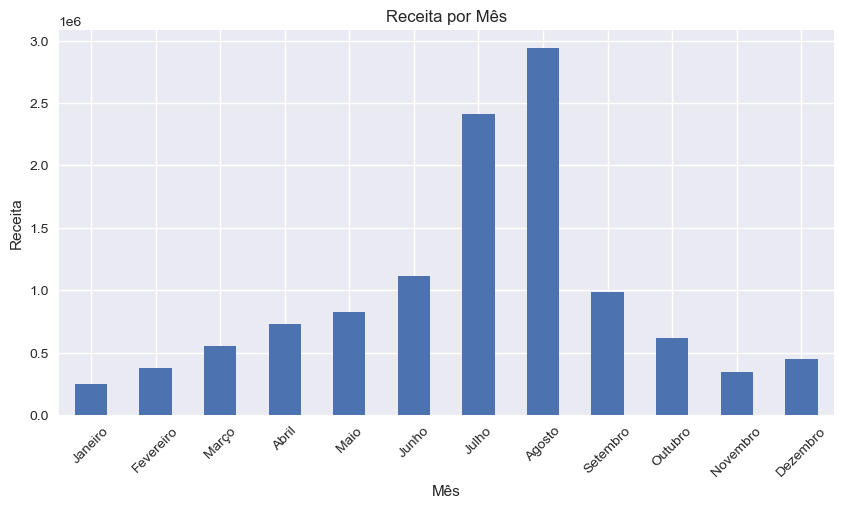

In [94]:
receita_mes = (
    df_confirmadas
    .groupby("mes_chegada_nome")["receita_reserva"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10,5))
receita_mes.plot(kind="bar")
plt.title("Receita por Mês")
plt.ylabel("Receita")
plt.xlabel("Mês")
plt.xticks(rotation=45)
plt.show()

## Receita por segmento de mercado

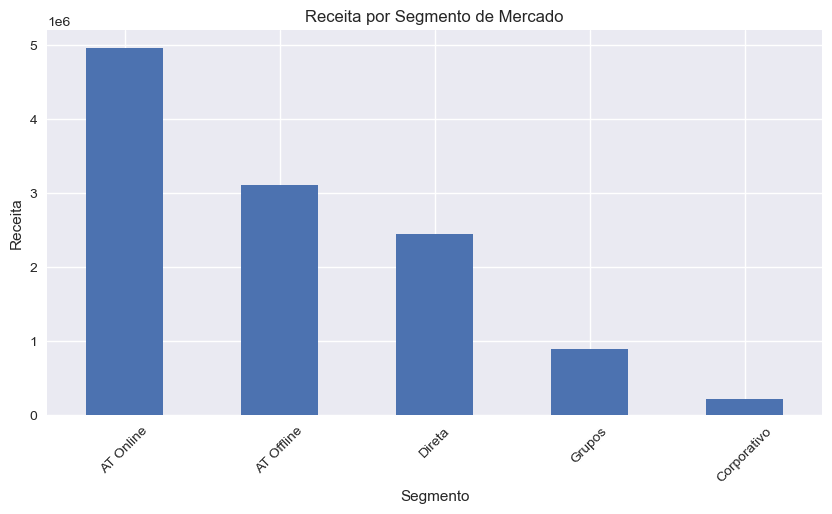

In [95]:
receita_segmento = (
    df_confirmadas
    .groupby("segmento_mercado")["receita_reserva"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
receita_segmento.plot(kind="bar")
plt.title("Receita por Segmento de Mercado")
plt.ylabel("Receita")
plt.xlabel("Segmento")
plt.xticks(rotation=45)
plt.show()

## Receita por tipo de quarto

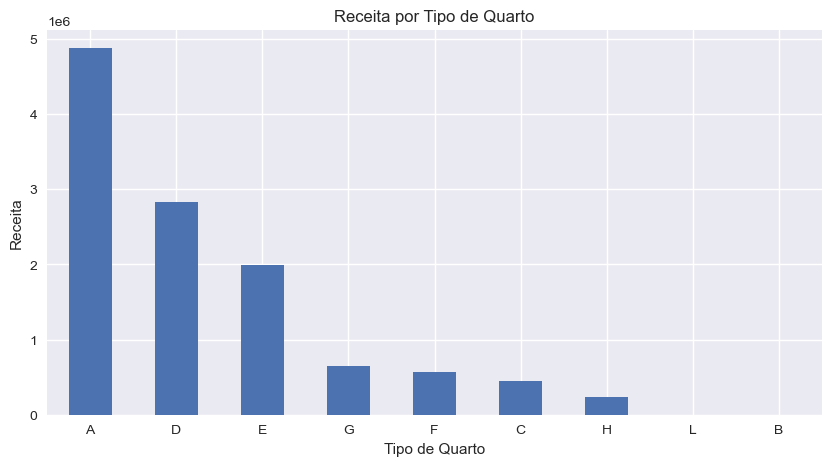

In [96]:
receita_quarto = (
    df_confirmadas
    .groupby("tipo_quarto")["receita_reserva"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
receita_quarto.plot(kind="bar")
plt.title("Receita por Tipo de Quarto")
plt.ylabel("Receita")
plt.xlabel("Tipo de Quarto")
plt.xticks(rotation=0)
plt.show()

## ADR por mês

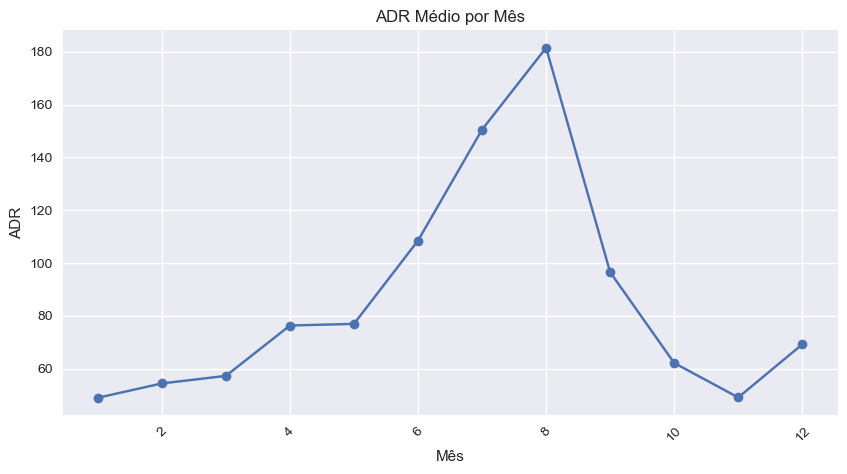

In [97]:
adr_mes = (
    df_confirmadas
    .groupby("mes_chegada")["receita_por_noite"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,5))
adr_mes.plot(kind="line", marker="o")
plt.title("ADR Médio por Mês")
plt.ylabel("ADR")
plt.xlabel("Mês")
plt.xticks(rotation=45)
plt.show()

# Análise exploratória de cancelamento

## Taxa de cancelamento por faixa de antecedência

A hipótese principal desta análise é que reservas feitas com maior antecedência apresentam maior risco de cancelamento.

C:\Users\Samanta\AppData\Local\Temp\ipykernel_16708\1571906548.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_antecedencia")["reserva_cancelada"]


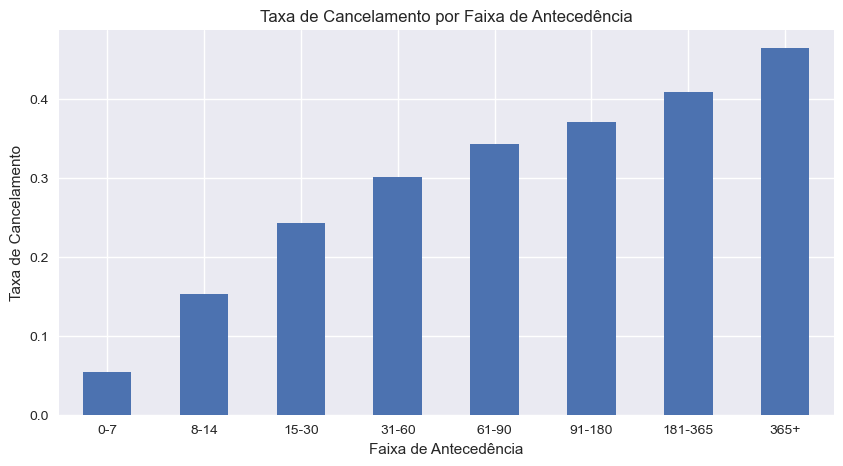

In [98]:
cancel_antecedencia = (
    df.groupby("faixa_antecedencia")["reserva_cancelada"]
    .mean()
)

plt.figure(figsize=(10,5))
cancel_antecedencia.plot(kind="bar")
plt.title("Taxa de Cancelamento por Faixa de Antecedência")
plt.ylabel("Taxa de Cancelamento")
plt.xlabel("Faixa de Antecedência")
plt.xticks(rotation=0)
plt.show()

In [99]:
(
    df.groupby("faixa_antecedencia")
    .agg(
        reservas=("reserva_cancelada", "count"),
        taxa_cancelamento=("reserva_cancelada", "mean")
    )
)

C:\Users\Samanta\AppData\Local\Temp\ipykernel_16708\1859383803.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_antecedencia")


,reservas,taxa_cancelamento
faixa_antecedencia,,
0-7,8838,0.053519
8-14,2423,0.152703
15-30,3920,0.243112
31-60,5062,0.300672
61-90,3666,0.342608
91-180,8207,0.370415
181-365,7299,0.408549
365+,444,0.463964


## Taxa de cancelamento por segmento

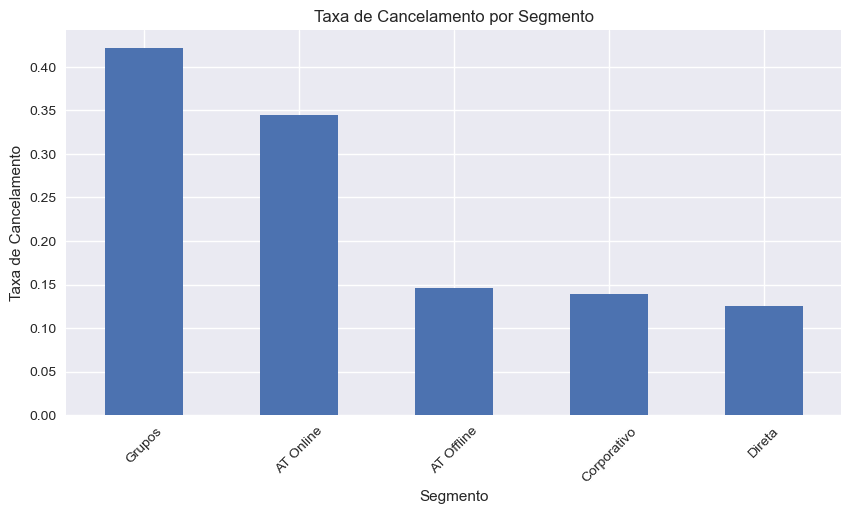

In [100]:
cancel_segmento = (
    df.groupby("segmento_mercado")["reserva_cancelada"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
cancel_segmento.plot(kind="bar")
plt.title("Taxa de Cancelamento por Segmento")
plt.ylabel("Taxa de Cancelamento")
plt.xlabel("Segmento")
plt.xticks(rotation=45)
plt.show()

## Taxa de cancelamento por recorrência

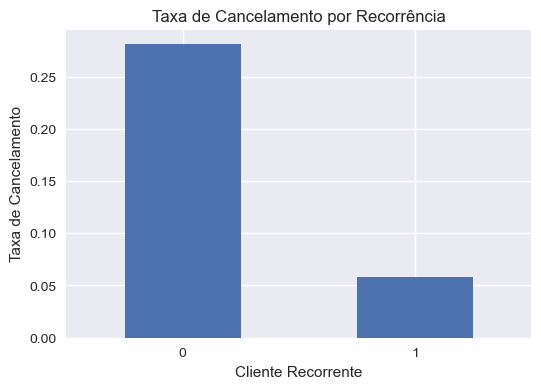

In [101]:
cancel_recorrente = (
    df.groupby("cliente_recorrente")["reserva_cancelada"]
    .mean()
)

plt.figure(figsize=(6,4))
cancel_recorrente.plot(kind="bar")
plt.title("Taxa de Cancelamento por Recorrência")
plt.ylabel("Taxa de Cancelamento")
plt.xlabel("Cliente Recorrente")
plt.xticks(rotation=0)
plt.show()

## Taxa de cancelamento por pedidos especiais


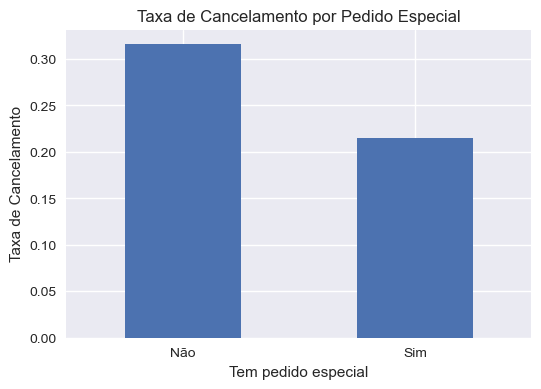

In [102]:
cancel_pedido = (
    df.groupby("tem_pedido_especial")["reserva_cancelada"]
    .mean()
)

plt.figure(figsize=(6,4))
cancel_pedido.plot(kind="bar")
plt.title("Taxa de Cancelamento por Pedido Especial")
plt.ylabel("Taxa de Cancelamento")
plt.xlabel("Tem pedido especial")
plt.xticks([0,1], ["Não", "Sim"], rotation=0)
plt.show()

# Principais drivers

## Tabela executiva por segmento

A tabela abaixo consolida volume, risco de cancelamento, receita e antecedência média por segmento.

In [103]:
resumo_segmento = (
    df.groupby("segmento_mercado")
    .agg(
        reservas=("segmento_mercado", "count"),
        taxa_cancelamento=("reserva_cancelada", "mean"),
        receita_total=("receita_reserva", "sum"),
        antecedencia_media=("tempo_antecedencia", "mean")
    )
    .sort_values("receita_total", ascending=False)
)

resumo_segmento

,reservas,taxa_cancelamento,receita_total,antecedencia_media
segmento_mercado,,,,
AT Online,17729,0.344859,8956803.08,83.270968
AT Offline,7472,0.146012,3676710.75,120.452489
Direta,6513,0.125595,2970496.88,48.457546
Grupos,5836,0.421350,1547645.69,167.213331
Corporativo,2309,0.138588,290226.64,17.657861


## Resumo dos principais drivers identificados

In [104]:
insights = pd.DataFrame({
    "driver": [
        "Antecedência da reserva",
        "Mix de segmentos",
        "Recorrência",
        "Pedidos especiais",
        "Sazonalidade"
    ],
    "evidencia": [
        "A taxa de cancelamento aumenta conforme cresce a antecedência",
        "Alguns segmentos concentram receita, mas também maior risco",
        "Clientes recorrentes tendem a cancelar menos",
        "Reservas com pedidos especiais parecem ter maior intenção real",
        "Receita e ADR se concentram em determinados meses"
    ],
    "implicacao_negocio": [
        "Revisar política comercial para reservas muito antecipadas",
        "Otimizar mix de canais e qualidade da aquisição",
        "Fortalecer ações de retenção e recompra",
        "Usar sinais comportamentais para priorização em CRM",
        "Aplicar estratégias de pricing e gestão de demanda"
    ]
})

insights

,driver,evidencia,implicacao_negocio
0,Antecedência da reserva,A taxa de cancelamento aumenta conforme cresce...,Revisar política comercial para reservas muito...
1,Mix de segmentos,"Alguns segmentos concentram receita, mas també...",Otimizar mix de canais e qualidade da aquisição
2,Recorrência,Clientes recorrentes tendem a cancelar menos,Fortalecer ações de retenção e recompra
3,Pedidos especiais,Reservas com pedidos especiais parecem ter mai...,Usar sinais comportamentais para priorização e...
4,Sazonalidade,Receita e ADR se concentram em determinados meses,Aplicar estratégias de pricing e gestão de dem...


# Cenários de aumento de receita

Em vez de projetar a receita apenas por técnicas de série temporal, foi adotada uma abordagem orientada a drivers de negócio, com simulações de alavancas práticas.

In [105]:
receita_atual = df_confirmadas["receita_reserva"].sum()

canceladas_online = df[
    (df["segmento_mercado"] == "AT Online") &
    (df["status_reserva"] == "Cancelada")
]["receita_reserva"].sum()

canceladas_grupos = df[
    (df["segmento_mercado"] == "Grupos") &
    (df["status_reserva"] == "Cancelada")
]["receita_reserva"].sum()

receita_direta = df_confirmadas[
    df_confirmadas["segmento_mercado"] == "Direta"
]["receita_reserva"].sum()

receita_jul_ago = df_confirmadas[
    df_confirmadas["mes_chegada_nome"].isin(["Julho", "Agosto"])
]["receita_reserva"].sum()

## As porcentagens de uplift usadas abaixo são hipóteses conservadoras baseadas em benchmarks de hotelaria e no impacto esperado de cada alavanca, evitando superestimar o potencial de crescimento.

In [106]:
uplift_online = canceladas_online * 0.05
uplift_grupos = canceladas_grupos * 0.08
uplift_direta = receita_direta * 0.10
uplift_pricing = receita_jul_ago * 0.03

cenarios = pd.DataFrame({
    "alavanca": [
        "Redução de cancelamento em AT Online",
        "Redução de cancelamento em Grupos",
        "Crescimento do canal Direta",
        "Aumento de preço em Julho e Agosto"
    ],
    "hipotese": [
        "redução de 5 p.p. no cancelamento",
        "redução de 8 p.p. no cancelamento",
        "crescimento de 10% na receita do canal",
        "aumento de 3% no preço em meses de pico"
    ],
    "upside_estimado": [
        uplift_online,
        uplift_grupos,
        uplift_direta,
        uplift_pricing
    ]
})

cenarios["% da receita atual"] = cenarios["upside_estimado"] / receita_atual
cenarios

,alavanca,hipotese,upside_estimado,% da receita atual
0,Redução de cancelamento em AT Online,redução de 5 p.p. no cancelamento,198061.7020,0.017075
1,Redução de cancelamento em Grupos,redução de 8 p.p. no cancelamento,52630.1944,0.004537
2,Crescimento do canal Direta,crescimento de 10% na receita do canal,244186.8500,0.021051
3,Aumento de preço em Julho e Agosto,aumento de 3% no preço em meses de pico,160569.3771,0.013842


In [107]:
upside_total = cenarios["upside_estimado"].sum()
pct_total = upside_total / receita_atual

print(f"Upside total estimado: {upside_total:,.2f}")
print(f"Upside sobre a receita atual: {pct_total:.2%}")

Upside total estimado: 655,448.12
Upside sobre a receita atual: 5.65%


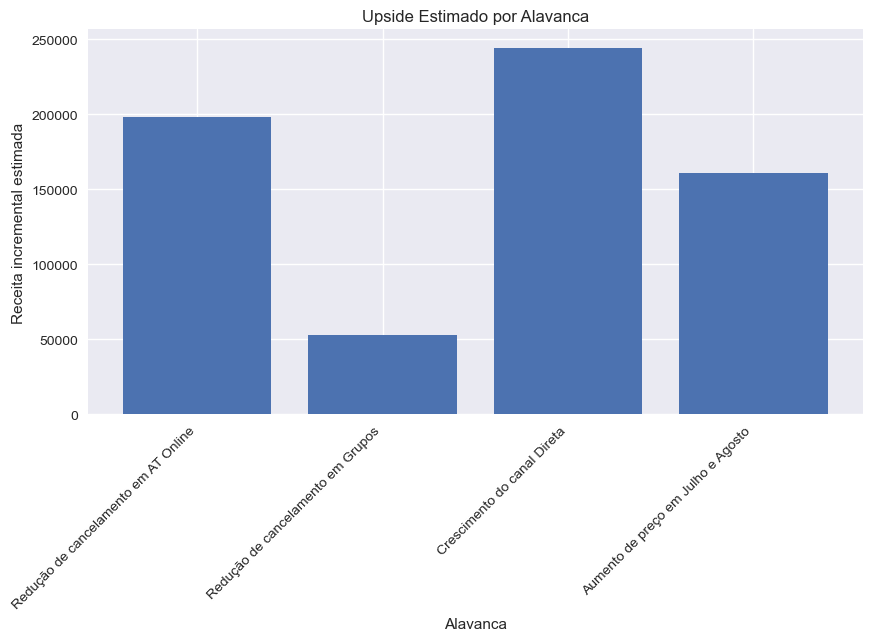

In [108]:
plt.figure(figsize=(10,5))
plt.bar(cenarios["alavanca"], cenarios["upside_estimado"])
plt.title("Upside Estimado por Alavanca")
plt.ylabel("Receita incremental estimada")
plt.xlabel("Alavanca")
plt.xticks(rotation=45, ha="right")
plt.show()

# Conclusões e recomendações

A análise mostra que o principal desafio do hotel não parece ser apenas gerar mais reservas, mas sim aumentar a qualidade e a conversão das reservas já existentes.

## Principais conclusões

- a taxa de cancelamento é elevada e representa um importante vazamento de receita
- reservas feitas com maior antecedência apresentam maior risco de cancelamento
- há diferenças relevantes entre segmentos em termos de receita e qualidade da reserva
- o hotel apresenta sazonalidade, com oportunidade de gestão de preço em períodos de pico
- sinais comportamentais como recorrência e pedidos especiais podem ajudar a identificar reservas de maior qualidade

## Recomendações prioritárias

1. Rever a política comercial para reservas feitas com muita antecedência
2. Melhorar o mix de segmentos e fortalecer canais mais saudáveis
3. Incentivar recorrência e canal direto
4. Aplicar pricing mais agressivo em períodos de maior demanda
5. Explorar estratégias de upsell em tipos de quarto com maior valor

In [110]:
base_pbi = df.copy()

base_pbi.to_excel("base_final_hotel_pbi.xlsx", index=False)

print("Base exportada com sucesso.")

Base exportada com sucesso.
